# Day 1 — micrograd
My autograd engine, from memory. Video first, then close it.

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph
import torch
import random
%matplotlib inline

In [22]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [23]:
class Value:
    def __init__(self, data, _children=(), label='', _op='') -> None:
        self.data = data
        self.label = label
        self._op = _op
        self._prev = set(_children)
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self) -> str:
        return f"Value ({self.data})"
    
    def __add__(self, other) -> Value:
        out = Value(self.data + other.data, (self, other), _op='+')

        def _backward():
            other.grad += 1 * out.grad
            self.grad += 1 * out.grad

        out._backward = _backward

        return out

    def __mul__(self, other) -> Value:
        out = Value(self.data * other.data, (self, other), _op='*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward

        return out

    def tanh(self) -> Value:
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - (out.data)**2) * out.grad
            
        out._backward = _backward

        return out

    def backward(self):

        def topological_sort(v):

            ordering = []
            visited = set()

            def grow_topological(v):
                if v not in visited:
                    visited.add(v)
                    for child in v._prev:
                        grow_topological(child)
                    ordering.append(v)

            grow_topological(v)

            return ordering

        self.grad = 1.0

        topo = topological_sort(self)

        for v in reversed(topo):
            # print(f'Calling _backward() on {v}')
            v._backward()



In [24]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label= 'f')
L = d*f; L.label = 'L'
L

Value (-8.0)

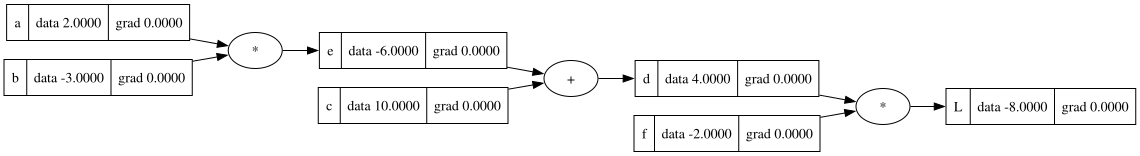

In [25]:
draw_dot(L)

Manual backpropagation

We know, derivate formula: (f(x+h) - f(x))/(h) 

dL/dL = 1

In [26]:
L.grad = 1

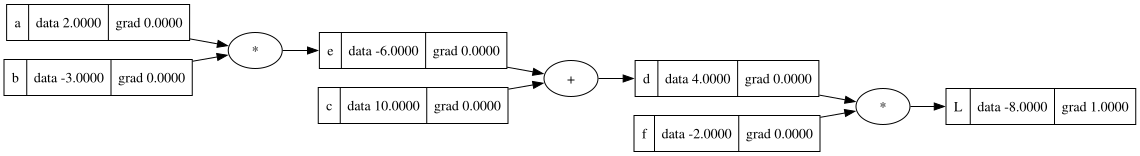

In [27]:
draw_dot(L)

What is the derivative of L with respect to d?

dL/dd = ?
L = d * f
dL/dd = f = -2

dL/df = ?
L = d * f
dL/df = d = 4

In [28]:
d.grad = -2
f.grad = 4

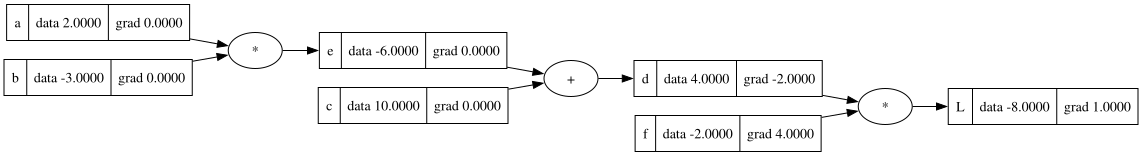

In [29]:
draw_dot(L)

What is the derivative of L with respect to c?

Using chain rule...

dL/dc = dL/dd * dd/dc

From what we know previously, 
dL/dd = -2
dd/dc = If you nudge c with a tiny number, how much will d move = ?

d = c + e
dd/dc = (d(c+h) - d(c))/h
= (c + e + h - c - e)/h = 1.0 = dd/dc

dL/dc = -2.0


dL/de = dL/dd * dd/de
dd/de = Nudge e with tiny num h, how much will d chnage = ?

d = c + e
= (d(e+h)-d(e))/h
= (c+e+h - c - e)/h = 1

dL/de = -2.0

In [30]:
e.grad = -2
c.grad = -2

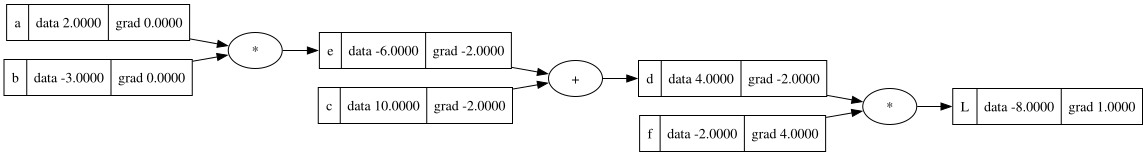

In [31]:
draw_dot(L)

e = a * b

de/db = d(ab)/db = a = 2

dL/db = dL/de * de/db
= -2 * 2
= -4

de/da = b

dL/da = dL/de * de/da
= -2 * -3
= 6

In [32]:
b.grad = -4
a.grad = 6

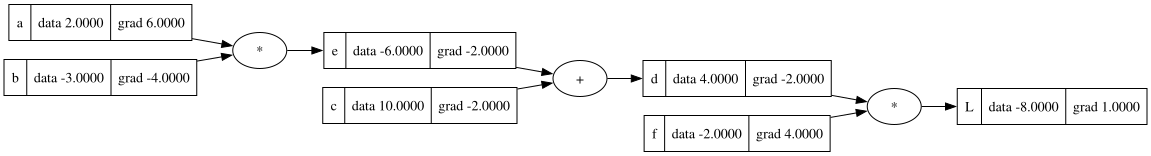

In [33]:
draw_dot(L)

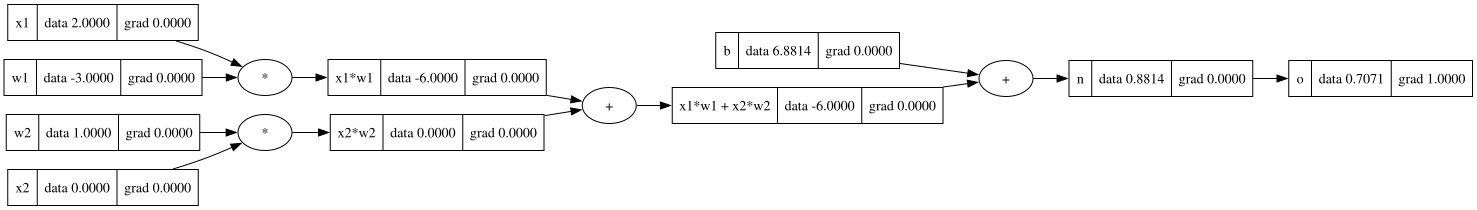

In [34]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.grad = 1
draw_dot(o)

Manual backpropagation of this example

o = tanh(n)

do/dn = d(tanh(n))/dn
= 1 - (tanh(n))**2
= 1 - o**2
= 1 - 0.7071
= 0.5

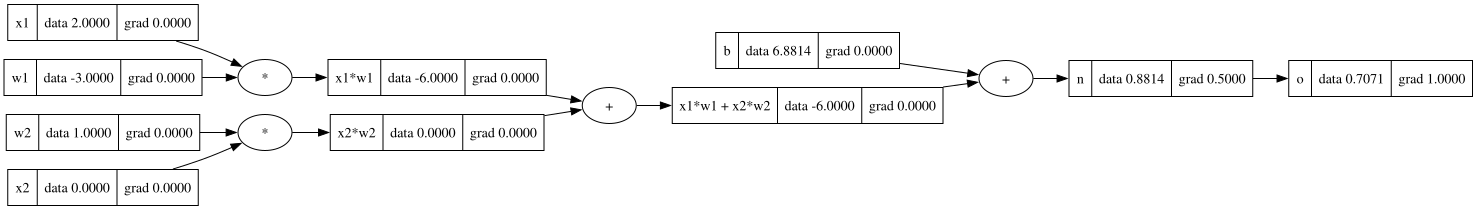

In [35]:
n.grad = 0.5
draw_dot(o)

x1w1+x2w2 = n + b

dn/db = (d(n+h)-d(n))/h
= ((x1w1+x2w2+h+b)-(x1w1+x2w2+b))/h
= 1


do/db = do/dn * dn/db = do/d(x1w1+x2w2)
= 0.5 * 1 
= 0.5

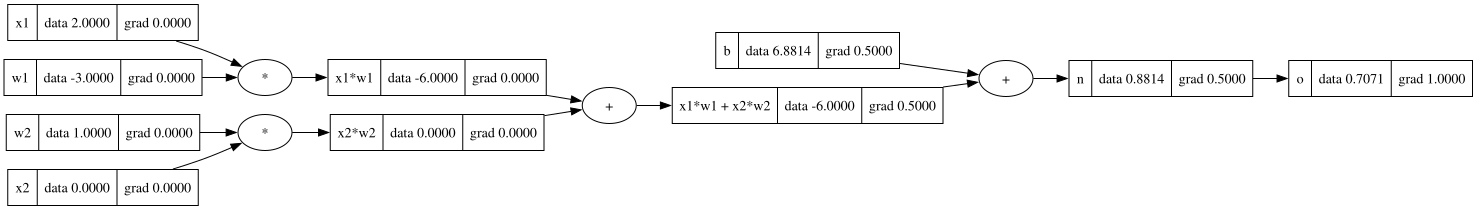

In [36]:
x1w1x2w2.grad = 0.5
b.grad = 0.5
draw_dot(o)

x2w2 + x1w1 = x1w1x2w2

dx1w1x2w2/dx2w2 = dx1w1x2w2/dx1w1 = (d(x1w1+h) - d(x1w1))/h
= (x1w1 + x2w2 + h - (x1w1 + x2w2))/h
= 1.0

do/dx1w1 = do/dx1w1x2w2 * dx1w1x2w2/dx1w1
= 0.5 * 1
= 0.5

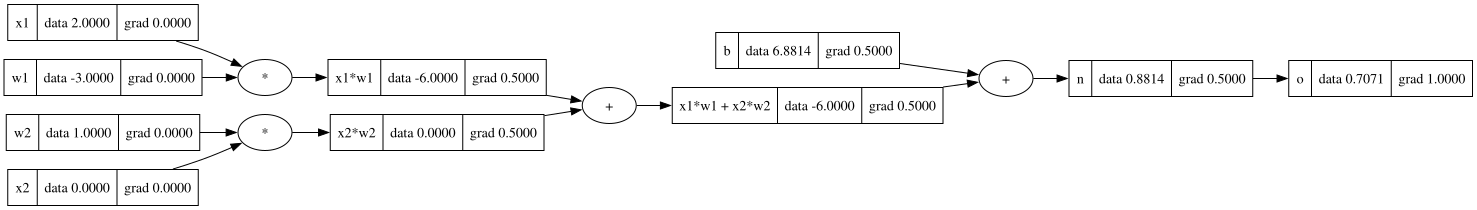

In [37]:
x2w2.grad = 0.5
x1w1.grad = 0.5
draw_dot(o)


x2w2 = x2 * w2
dx2w2/dx2 = w2

x2w2 = x2 * w2
dx2w2/dw2 = x2

do/dw2 = do/dx2w2 * dx2w2/dw2 = 0.5 * 0 = 0
do/dx2 = do/dx2w2 * dx2w2/dx2 = 0.5 * 1 = 0.5

x1w1 = x1 * w1
dx1w1/dx1 = w1

x1w1 = x1 * w1
dx1w1/dw1 = x1

do/dw1 = do/dx1w1 * dx1w1/dw1 = 0.5 * 2 = 1
do/dx1 = do/dx1w1 * dx1w1/dx1 = 0.5 * -3 = -1.5

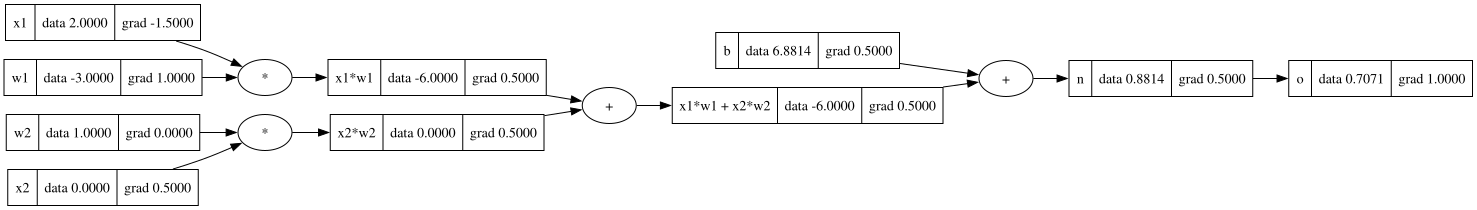

In [38]:
w2.grad = 0
x2.grad = 0.5
w1.grad = 1
x1.grad = -1.5
draw_dot(o)

In [39]:
def incode_bp():
    # inputs x1, x2
    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')

    # weights w1, w2
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')

    # bias of the neuron
    b = Value(6.8813735870195432, label='b')

    # x1*w1 + x2*w2 + b
    x1w1 = x1 * w1; x1w1.label = 'x1*w1'
    x2w2 = x2 * w2; x2w2.label = 'x2*w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
    n = x1w1x2w2 + b; n.label = 'n'
    o = n.tanh(); o.label = 'o'
    o.backward()
    return draw_dot(o)

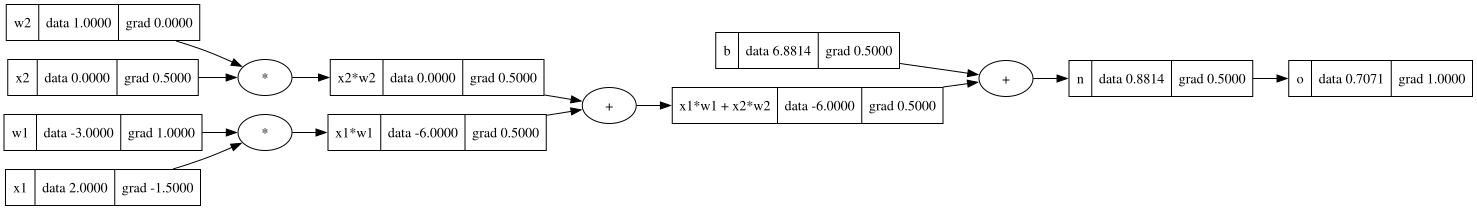

In [40]:
incode_bp()